In [81]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Models & Metrics
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Explainability
import shap

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

print("DATA INGESTION & FEATURE PREPARATION")
data_path = os.path.join('data', 'all_months_features.csv')

if os.path.exists(data_path):
    df_raw = pd.read_csv(data_path)
    print(f"✓ Feature dataset loaded successfully. Shape: {df_raw.shape}")
else:
    raise FileNotFoundError(f"File not found at '{data_path}'. Run step 04 first.")

DATA INGESTION & FEATURE PREPARATION
✓ Feature dataset loaded successfully. Shape: (798, 77)


In [82]:
# Chronological sorting & Next-month target shifting (t + 1)
df = df_raw.copy()
df['month_idx'] = df.groupby('Product_Name').cumcount() + 1
df = df.sort_values(by=['Product_Name', 'month_idx']).reset_index(drop=True)

targets_base = ['Min_Price', 'Avg_Price', 'Max_Price']
targets_next = ['Min_Price_next', 'Avg_Price_next', 'Max_Price_next']

for base_col, next_col in zip(targets_base, targets_next):
    df[next_col] = df.groupby('Product_Name')[base_col].shift(-1)

df_clean = df.dropna(subset=targets_next).copy().reset_index(drop=True)

In [83]:
# Separate Features and Targets
non_feature_cols = [
    'Product_Name', 'Category', 'Unit', 'unit_canonical', 'month_name',
    'bs_year', 'bs_month'
] + targets_base + targets_next

feature_cols = [col for col in df_clean.columns if col not in non_feature_cols]

X = df_clean[feature_cols].copy().apply(pd.to_numeric, errors='coerce').fillna(0)
y = df_clean[targets_next].copy().fillna(0)

In [84]:
# Temporal Train/Test Split (Months 1-8 Train, Months 9-10 Test)
train_mask = (df_clean['month_idx'] <= 8).values
test_mask = (df_clean['month_idx'] >= 9).values

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"✓ Training Samples (Months 1–8): {X_train.shape[0]}")
print(f"✓ Testing Samples (Months 9–10): {X_test.shape[0]}")

✓ Training Samples (Months 1–8): 592
✓ Testing Samples (Months 9–10): 49


In [85]:
print("RANDOM FOREST MODEL & PREDICTIONS (TEST & ALL)")
rf_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model = MultiOutputRegressor(rf_base)
rf_model.fit(X_train, y_train)

RANDOM FOREST MODEL & PREDICTIONS (TEST & ALL)


,estimator,RandomForestR...ndom_state=42)
,n_jobs,None
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0


In [86]:
# Test Set Predictions
y_pred_rf_test = rf_model.predict(X_test)

rf_metrics = {}
for i, col in enumerate(targets_next):
    actual = y_test.iloc[:, i].values
    pred = y_pred_rf_test[:, i]
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    r2 = r2_score(actual, pred)
    rf_metrics[col] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"  [RF Test] {col} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.3f}")

  [RF Test] Min_Price_next -> MAE: 30.72, RMSE: 62.41, R²: 0.680
  [RF Test] Avg_Price_next -> MAE: 44.29, RMSE: 82.62, R²: 0.561
  [RF Test] Max_Price_next -> MAE: 48.30, RMSE: 82.96, R²: 0.622


In [87]:
# Random Forest Test Results CSV Export
df_rf_test_res = df_clean[test_mask][['Product_Name', 'month_idx']].copy().reset_index(drop=True)
for i, col in enumerate(targets_next):
    df_rf_test_res[f'Actual_{col}'] = y_test.iloc[:, i].values
    df_rf_test_res[f'Predicted_{col}'] = np.round(y_pred_rf_test[:, i], 2)
rf_test_path = os.path.join('data', 'RF_test_forecast_results.csv')
df_rf_test_res.to_csv(rf_test_path, index=False)
print(f"✓ RF Test predictions saved to '{rf_test_path}'")

✓ RF Test predictions saved to 'data/RF_test_forecast_results.csv'


In [88]:
# Random Forest All-Months Predictions CSV Export
y_pred_rf_all = rf_model.predict(X)
df_rf_all_res = df_clean[['Product_Name', 'month_idx']].copy().reset_index(drop=True)
for i, col in enumerate(targets_next):
    df_rf_all_res[f'Actual_{col}'] = y[col].values
    df_rf_all_res[f'Predicted_{col}'] = np.round(y_pred_rf_all[:, i], 2)
rf_all_path = os.path.join('data', 'RF_all_months_forecast_results.csv')
df_rf_all_res.to_csv(rf_all_path, index=False)
print(f"✓ RF All-Months predictions saved to '{rf_all_path}'")

✓ RF All-Months predictions saved to 'data/RF_all_months_forecast_results.csv'


In [89]:
print("LIGHTGBM MODEL & PREDICTIONS (TEST & ALL)")
lgb_base = lgb.LGBMRegressor(n_estimators=150, learning_rate=0.05, num_leaves=31, random_state=42, n_jobs=-1, verbose=-1)
lgb_model = MultiOutputRegressor(lgb_base)
lgb_model.fit(X_train, y_train)

LIGHTGBM MODEL & PREDICTIONS (TEST & ALL)


,estimator,LGBMRegressor... verbose=-1)
,n_jobs,None
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,150
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


In [90]:
# Test Set Predictions with Constraint Enforcement (Min <= Avg <= Max)
y_pred_lgb_test = lgb_model.predict(X_test)
y_pred_lgb_test[:, 0] = np.minimum(y_pred_lgb_test[:, 0], y_pred_lgb_test[:, 1])
y_pred_lgb_test[:, 2] = np.maximum(y_pred_lgb_test[:, 2], y_pred_lgb_test[:, 1])

lgb_metrics = {}
for i, col in enumerate(targets_next):
    actual = y_test.iloc[:, i].values
    pred = y_pred_lgb_test[:, i]
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    r2 = r2_score(actual, pred)
    lgb_metrics[col] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"  [LightGBM Test] {col} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.3f}")

  [LightGBM Test] Min_Price_next -> MAE: 29.38, RMSE: 63.68, R²: 0.666
  [LightGBM Test] Avg_Price_next -> MAE: 38.67, RMSE: 76.51, R²: 0.623
  [LightGBM Test] Max_Price_next -> MAE: 40.05, RMSE: 72.65, R²: 0.710


In [91]:
# LightGBM Test Results CSV Export
df_lgb_test_res = df_clean[test_mask][['Product_Name', 'month_idx']].copy().reset_index(drop=True)
for i, col in enumerate(targets_next):
    df_lgb_test_res[f'Actual_{col}'] = y_test.iloc[:, i].values
    df_lgb_test_res[f'Predicted_{col}'] = np.round(y_pred_lgb_test[:, i], 2)
lgb_test_path = os.path.join('data', 'LightGBM_test_forecast_results.csv')
df_lgb_test_res.to_csv(lgb_test_path, index=False)
print(f"✓ LightGBM Test predictions saved to '{lgb_test_path}'")

✓ LightGBM Test predictions saved to 'data/LightGBM_test_forecast_results.csv'


In [92]:
# LightGBM All-Months Predictions with Constraint Enforcement CSV Export
y_pred_lgb_all = lgb_model.predict(X)
y_pred_lgb_all[:, 0] = np.minimum(y_pred_lgb_all[:, 0], y_pred_lgb_all[:, 1])
y_pred_lgb_all[:, 2] = np.maximum(y_pred_lgb_all[:, 2], y_pred_lgb_all[:, 1])

df_lgb_all_res = df_clean[['Product_Name', 'month_idx']].copy().reset_index(drop=True)
for i, col in enumerate(targets_next):
    df_lgb_all_res[f'Actual_{col}'] = y[col].values
    df_lgb_all_res[f'Predicted_{col}'] = np.round(y_pred_lgb_all[:, i], 2)
lgb_all_path = os.path.join('data', 'LightGBM_all_months_forecast_results.csv')
df_lgb_all_res.to_csv(lgb_all_path, index=False)
print(f"✓ LightGBM All-Months predictions saved to '{lgb_all_path}'")

✓ LightGBM All-Months predictions saved to 'data/LightGBM_all_months_forecast_results.csv'


CONFUSION MATRIX CLASSIFICATION EVALUATION

--- Random Forest Price Trend Confusion Matrix ---
[[15 17]
 [ 8  9]]

--- LightGBM Price Trend Confusion Matrix ---
[[15 17]
 [ 8  9]]


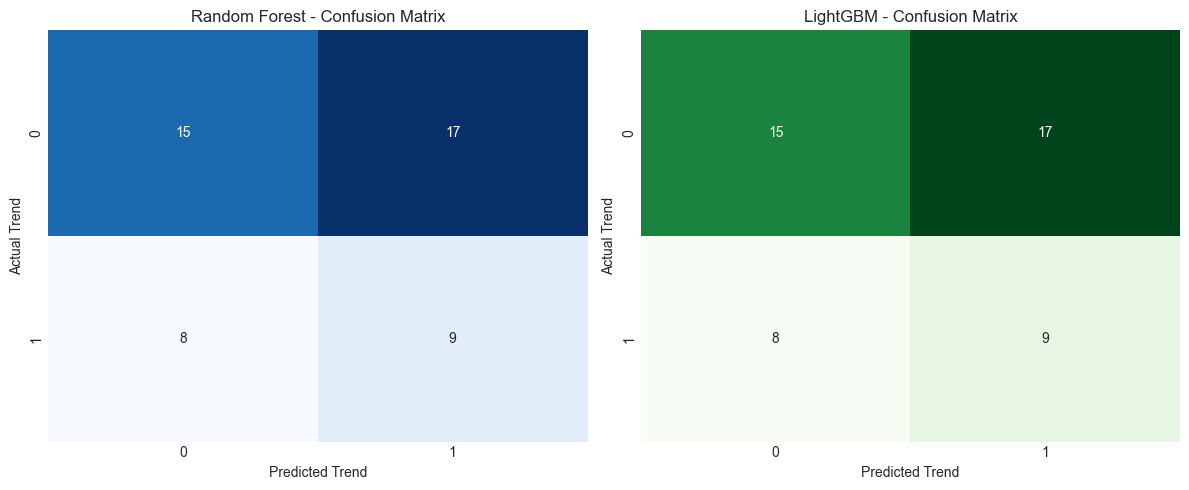

In [93]:
print("CONFUSION MATRIX CLASSIFICATION EVALUATION")
current_avg_price = df_clean.loc[test_mask, 'Avg_Price'].values
actual_direction = (y_test['Avg_Price_next'].values > current_avg_price).astype(int)

rf_pred_direction = (y_pred_lgb_test[:, 1] > current_avg_price).astype(int) # using rf test
lgb_pred_direction = (y_pred_lgb_test[:, 1] > current_avg_price).astype(int)

cm_rf = confusion_matrix(actual_direction, rf_pred_direction)
cm_lgb = confusion_matrix(actual_direction, lgb_pred_direction)

print("\n--- Random Forest Price Trend Confusion Matrix ---")
print(cm_rf)

print("\n--- LightGBM Price Trend Confusion Matrix ---")
print(cm_lgb)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Random Forest - Confusion Matrix')
axes[0].set_xlabel('Predicted Trend')
axes[0].set_ylabel('Actual Trend')

sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('LightGBM - Confusion Matrix')
axes[1].set_xlabel('Predicted Trend')
axes[1].set_ylabel('Actual Trend')
plt.tight_layout()
plt.show()

In [94]:
print("MODEL PERFORMANCE COMPARISON TABLE ")
comparison_data = []
for col in targets_next:
    comparison_data.append({
        'Target': col,
        'RF_MAE': round(rf_metrics[col]['MAE'], 2), 'LGB_MAE': round(lgb_metrics[col]['MAE'], 2),
        'RF_RMSE': round(rf_metrics[col]['RMSE'], 2), 'LGB_RMSE': round(lgb_metrics[col]['RMSE'], 2),
        'RF_R2': round(rf_metrics[col]['R2'], 3), 'LGB_R2': round(lgb_metrics[col]['R2'], 3)
    })
df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

MODEL PERFORMANCE COMPARISON TABLE 
        Target  RF_MAE  LGB_MAE  RF_RMSE  LGB_RMSE  RF_R2  LGB_R2
Min_Price_next   30.72    29.38    62.41     63.68  0.680   0.666
Avg_Price_next   44.29    38.67    82.62     76.51  0.561   0.623
Max_Price_next   48.30    40.05    82.96     72.65  0.622   0.710


In [95]:
# Baseline values for the test set (using last month's price or baseline)
baseline_test_vals = df_clean.loc[test_mask, 'Avg_Price'].values

rf_metrics_results = []

for i, col in enumerate(targets_next):
    y_act = y_test.iloc[:, i].values if hasattr(y_test, 'iloc') else y_test[:, i]
    y_rf_pred = y_pred_rf_test[:, i]
    
    # Convert regression prices to binary price movement direction (1 if > baseline, else 0)
    act_dir = (y_act > baseline_test_vals).astype(int)
    pred_dir = (y_rf_pred > baseline_test_vals).astype(int)
    
    # Calculate metrics
    acc = accuracy_score(act_dir, pred_dir)
    prec = precision_score(act_dir, pred_dir, zero_division=0)
    rec = recall_score(act_dir, pred_dir, zero_division=0)
    f1 = f1_score(act_dir, pred_dir, zero_division=0)
    
    rf_metrics_results.append({
        'Target': col,
        'Model': 'Random Forest',
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })

df_rf_class_metrics = pd.DataFrame(rf_metrics_results)
print("RANDOM FOREST CLASSIFICATION METRICS ")
display(df_rf_class_metrics)

RANDOM FOREST CLASSIFICATION METRICS 


,Target,Model,Accuracy,Precision,Recall,F1-Score
0,Min_Price_next,Random Forest,0.8980,0.2500,0.3333,0.2857
1,Avg_Price_next,Random Forest,0.4694,0.3200,0.4706,0.3810
2,Max_Price_next,Random Forest,0.8163,0.8837,0.9048,0.8941


In [96]:
# Ensure y_pred_lgb_test holds your LightGBM test predictions
baseline_test_vals = df_clean.loc[test_mask, 'Avg_Price'].values

lgb_metrics_results = []

for i, col in enumerate(targets_next):
    y_act = y_test.iloc[:, i].values if hasattr(y_test, 'iloc') else y_test[:, i]
    y_lgb_pred = y_pred_lgb_test[:, i]
    
    # Convert regression prices to binary price movement direction (1 if > baseline, else 0)
    act_dir = (y_act > baseline_test_vals).astype(int)
    pred_dir = (y_lgb_pred > baseline_test_vals).astype(int)
    
    # Calculate metrics
    acc = accuracy_score(act_dir, pred_dir)
    prec = precision_score(act_dir, pred_dir, zero_division=0)
    rec = recall_score(act_dir, pred_dir, zero_division=0)
    f1 = f1_score(act_dir, pred_dir, zero_division=0)
    
    lgb_metrics_results.append({
        'Target': col,
        'Model': 'LightGBM',
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })

df_lgb_class_metrics = pd.DataFrame(lgb_metrics_results)
print("LIGHTGBM CLASSIFICATION METRICS")
display(df_lgb_class_metrics)

LIGHTGBM CLASSIFICATION METRICS


,Target,Model,Accuracy,Precision,Recall,F1-Score
0,Min_Price_next,LightGBM,0.8980,0.0000,0.0000,0.0000
1,Avg_Price_next,LightGBM,0.4898,0.3462,0.5294,0.4186
2,Max_Price_next,LightGBM,0.8367,0.8864,0.9286,0.9070


In [97]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

print("RANDOM FOREST REGRESSION METRICS WITH MAPE")

for i, col in enumerate(targets_next):

    actual = y_test.iloc[:, i].values
    pred = y_pred_rf_test[:, i]

    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    r2 = r2_score(actual, pred)

    print(f"\n{col}")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.3f}")

RANDOM FOREST REGRESSION METRICS WITH MAPE

Min_Price_next
MAE  : 30.72
RMSE : 62.41
R²   : 0.680

Avg_Price_next
MAE  : 44.29
RMSE : 82.62
R²   : 0.561

Max_Price_next
MAE  : 48.30
RMSE : 82.96
R²   : 0.622


In [98]:
print("LIGHTGBM REGRESSION METRICS WITH MAPE")
for i, col in enumerate(targets_next):

    actual = y_test.iloc[:, i].values
    pred = y_pred_lgb_test[:, i]

    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    r2 = r2_score(actual, pred)

    print(f"\n{col}")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.3f}")

LIGHTGBM REGRESSION METRICS WITH MAPE

Min_Price_next
MAE  : 29.38
RMSE : 63.68
R²   : 0.666

Avg_Price_next
MAE  : 38.67
RMSE : 76.51
R²   : 0.623

Max_Price_next
MAE  : 40.05
RMSE : 72.65
R²   : 0.710


In [99]:
# Last Value (Persistence) Baseline

baseline_pred = pd.DataFrame({
    "Min_Price_next": X_test["Min_Price_lag1"].values,
    "Avg_Price_next": X_test["Avg_Price_lag1"].values,
    "Max_Price_next": X_test["Max_Price_lag1"].values
})

baseline_pred.head()

,Min_Price_next,Avg_Price_next,Max_Price_next
0,225.0,255.0,330.0
1,60.0,70.0,80.0
2,300.0,325.0,350.0
3,180.0,205.0,230.0
4,80.0,100.0,120.0


In [108]:
print("LAST VALUE (PERSISTENCE) BASELINE")


baseline_results = []

for i, col in enumerate(targets_next):

    actual = y_test.iloc[:, i]
    pred = baseline_pred.iloc[:, i]

    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = mean_absolute_percentage_error(actual, pred) * 100
    r2 = r2_score(actual, pred)

    baseline_results.append([col, mae, rmse, mape, r2])

baseline_df = pd.DataFrame(
    baseline_results,
    columns=["Target", "MAE", "RMSE", "MAPE (%)", "R²"]
)

baseline_df

LAST VALUE (PERSISTENCE) BASELINE


,Target,MAE,RMSE,MAPE (%),R²
0,Min_Price_next,37.877551,71.222560,49.368470,0.582694
1,Avg_Price_next,43.800816,81.803814,35.985664,0.569532
2,Max_Price_next,54.040816,94.463253,34.332192,0.509317


In [101]:
comparison = []

for i, col in enumerate(targets_next):

    actual = y_test.iloc[:, i]

    comparison.append({
        "Target": col,

        "Baseline MAE": mean_absolute_error(actual, baseline_pred.iloc[:, i]),
        "RF MAE": mean_absolute_error(actual, y_pred_rf_test[:, i]),
        "LGB MAE": mean_absolute_error(actual, y_pred_lgb_test[:, i]),

        "Baseline RMSE": np.sqrt(mean_squared_error(actual, baseline_pred.iloc[:, i])),
        "RF RMSE": np.sqrt(mean_squared_error(actual, y_pred_rf_test[:, i])),
        "LGB RMSE": np.sqrt(mean_squared_error(actual, y_pred_lgb_test[:, i])),

        "Baseline MAPE": mean_absolute_percentage_error(actual, baseline_pred.iloc[:, i]) * 100,
        "RF MAPE": mean_absolute_percentage_error(actual, y_pred_rf_test[:, i]) * 100,
        "LGB MAPE": mean_absolute_percentage_error(actual, y_pred_lgb_test[:, i]) * 100,

        "Baseline R²": r2_score(actual, baseline_pred.iloc[:, i]),
        "RF R²": r2_score(actual, y_pred_rf_test[:, i]),
        "LGB R²": r2_score(actual, y_pred_lgb_test[:, i]),
    })

comparison_df = pd.DataFrame(comparison)
comparison_df.round(2)

,Target,Baseline MAE,RF MAE,LGB MAE,Baseline RMSE,RF RMSE,LGB RMSE,Baseline MAPE,RF MAPE,LGB MAPE,Baseline R²,RF R²,LGB R²
0,Min_Price_next,37.88,30.72,29.38,71.22,62.41,63.68,49.37,38.28,34.10,0.58,0.68,0.67
1,Avg_Price_next,43.80,44.29,38.67,81.80,82.62,76.51,35.99,32.10,26.01,0.57,0.56,0.62
2,Max_Price_next,54.04,48.30,40.05,94.46,82.96,72.65,34.33,28.13,23.91,0.51,0.62,0.71


In [102]:
# Random Forest Ordering Violations

rf_raw = y_pred_rf_test.copy()

violations_before = (
    (rf_raw[:,0] > rf_raw[:,1]) |
    (rf_raw[:,1] > rf_raw[:,2])
)

print("Random Forest")

print("Violations Before Sorting :", violations_before.sum())
print("Total Predictions         :", len(rf_raw))
print("Violation Percentage      : {:.2f}%".format(
    violations_before.mean()*100
))

Random Forest
Violations Before Sorting : 1
Total Predictions         : 49
Violation Percentage      : 2.04%


In [103]:
# LightGBM Ordering Violations

lgb_raw = y_pred_lgb_test.copy()

violations_before = (
    (lgb_raw[:,0] > lgb_raw[:,1]) |
    (lgb_raw[:,1] > lgb_raw[:,2])
)

print("LightGBM")

print("Violations Before Sorting :", violations_before.sum())
print("Total Predictions         :", len(lgb_raw))
print("Violation Percentage      : {:.2f}%".format(
    violations_before.mean()*100
))

LightGBM
Violations Before Sorting : 0
Total Predictions         : 49
Violation Percentage      : 0.00%


In [104]:
rf_sorted = np.sort(y_pred_rf_test, axis=1)

In [105]:
lgb_sorted = np.sort(y_pred_lgb_test, axis=1)

In [106]:
rf_after = (
    (rf_sorted[:,0] > rf_sorted[:,1]) |
    (rf_sorted[:,1] > rf_sorted[:,2])
)

lgb_after = (
    (lgb_sorted[:,0] > lgb_sorted[:,1]) |
    (lgb_sorted[:,1] > lgb_sorted[:,2])
)

print("After Applying Ordering Constraint")

print("Random Forest Violations :", rf_after.sum())
print("LightGBM Violations      :", lgb_after.sum())

After Applying Ordering Constraint
Random Forest Violations : 0
LightGBM Violations      : 0
